# RQ1 and RQ2: Course Baselines versus Advanced Semantic Clustering
# RQ1与RQ2：课程基线与高级语义聚类比较

This notebook compares clustering methods on the same cleaned Reddit corpus. It uses only the cleaned Parquet file and does not read or use stance scores.

本notebook在同一份清洗后的Reddit语料上比较聚类方法。它只读取清洗后的Parquet文件，不读取也不使用stance分数。

RQ1: What recurring climate and energy discussion themes appear in the six communities?

RQ1：六个社区中出现了哪些反复出现的气候与能源讨论主题？

RQ2: How do the distributions of those themes differ across communities?

RQ2：这些主题在不同社区中的分布有何差异？

Course baseline: TF-IDF, LSA, K-means++, Ward hierarchical clustering, and DBSCAN.

课程基线：TF-IDF、LSA、K-means++、Ward层次聚类和DBSCAN。

Advanced method: Sentence Transformer embeddings, UMAP, HDBSCAN, and c-TF-IDF topic descriptions.

高级方法：Sentence Transformer语义向量、UMAP、HDBSCAN和c-TF-IDF主题描述。

## 1. Setup and reproducible scope / 1. 设置与可复现研究范围

Install missing open-source packages, import the libraries, and fix all paths and analytical settings.

安装缺失的开源依赖，导入工具，并固定路径及全部分析设置。

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pyarrow": "pyarrow",
    "sentence_transformers": "sentence-transformers",
    "umap": "umap-learn",
    "hdbscan": "hdbscan",
}
missing_packages = [
    package for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import json
import platform
import time
import warnings
from itertools import combinations
from pathlib import Path

import hdbscan
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import seaborn as sns
import sklearn
import torch
from hdbscan.prediction import approximate_predict
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.sparse import diags
from scipy.stats import chi2_contingency

# Text-only compatibility guard. Some Python environments contain torchvision
# or torchaudio builds that do not match the installed torch build. Transformers
# may try to import those optional packages even though this notebook uses only
# text. Mark them unavailable inside Transformers without uninstalling anything.
import transformers.utils as transformers_utils
import transformers.utils.import_utils as transformers_import_utils

for optional_check in [
    "is_torchvision_available",
    "is_torchvision_v2_available",
    "is_torchaudio_available",
    "is_vision_available",
]:
    setattr(transformers_import_utils, optional_check, lambda: False)
    setattr(transformers_utils, optional_check, lambda: False)

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import Normalizer, normalize

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

BASE_DIR = Path(r"D:\DM1_project")
DATA_PATH = BASE_DIR / "reddit_opinion_climate_change_cleaned_final.parquet"
OUTPUT_DIR = BASE_DIR / "baseline_vs_advanced_outputs"
CACHE_DIR = OUTPUT_DIR / "cache"

SELECTED_SUBREDDITS = [
    "climatechange", "climate", "energy",
    "Futurology", "conspiracy", "changemyview",
]
DEDICATED_SUBREDDITS = {"climatechange", "climate", "energy"}
BROAD_SUBREDDITS = {"Futurology", "conspiracy", "changemyview"}

START_DATE = pd.Timestamp("2023-11-19")
END_EXCLUSIVE = pd.Timestamp("2026-09-01")
MIN_WORDS = 20
MAX_COMMENTS_PER_POST = 100
MAX_TRAIN_PER_SUBREDDIT = 15_000
COURSE_SAMPLE_PER_SUBREDDIT = 500
K_VALUES = list(range(4, 13))
RANDOM_STATE = 42
LSA_COMPONENTS = 100
BASELINE_K_OVERRIDE = None

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_BATCH_SIZE = 128
UMAP_COMPONENTS = 10
UMAP_NEIGHBORS = 30
HDBSCAN_MIN_CLUSTER_SIZES = [300, 600, 1200]
HDBSCAN_MIN_SAMPLES = [10, 30]
ADVANCED_PARAMETER_OVERRIDE = None
FULL_ASSIGNMENT_CHUNK_SIZE = 20_000
ASSIGN_FULL_CORPUS = True

HIGH_PRECISION_TITLE_PATTERN = (
    r"(?i)\b(?:climat(?:e|ic|ology|ologist|ologists)|global\s+warming|"
    r"greenhouse\s+(?:gas|gases|effect)|carbon\s+(?:emission|emissions|tax|capture|budget)|"
    r"co2|methane|net\s+zero|decarbon\w*|fossil\s+fuels?|renewable\s+energy|"
    r"clean\s+energy|solar\s+(?:energy|power|panel|panels)|wind\s+(?:energy|power|turbine|turbines)|"
    r"coal|oil\s+(?:industry|companies|company|production|drilling)|natural\s+gas|"
    r"energy\s+(?:transition|policy|crisis|system|systems|market|markets|grid|security)|"
    r"electric\s+vehicles?|evs?|nuclear\s+(?:power|energy)|reactors?|uranium|"
    r"sea\s+level|ice\s+sheets?|glaciers?|heat\s*waves?|droughts?|wildfires?|"
    r"climate\s+(?:policy|action|change|crisis|science|denial|denier|deniers))\b"
)

USE_COLUMNS = [
    "comment_id", "clean_text", "subreddit", "created_time", "post_id",
    "post_title", "author_name", "score", "controversiality",
    "comment_word_count", "post_score", "post_upvote_ratio",
]

assert DATA_PATH.exists(), f"Input file not found: {DATA_PATH}"
print("Input:", DATA_PATH)
print("Output:", OUTPUT_DIR)
print("Communities:", ", ".join(SELECTED_SUBREDDITS))
print("Time window:", START_DATE.date(), "to", (END_EXCLUSIVE - pd.Timedelta(days=1)).date())
print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("Torch device available:", "cuda" if torch.cuda.is_available() else "cpu")

d:\python 3.13.7\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input: D:\DM1_project\reddit_opinion_climate_change_cleaned_final.parquet
Output: D:\DM1_project\baseline_vs_advanced_outputs
Communities: climatechange, climate, energy, Futurology, conspiracy, changemyview
Time window: 2023-11-19 to 2026-08-31
Python: 3.13.7
scikit-learn: 1.7.2
Torch device available: cpu


Result guide: The printed paths, communities, dates, package versions, and available device should match the intended experiment.

结果说明：输出的路径、社区、日期、软件版本和计算设备应与实验设计一致。

## 2. Load data and apply a stricter relevance gate / 2. 读取数据并应用更严格的相关性筛选

Dedicated climate and energy communities are retained. Broad communities are retained only when the post title contains a high-precision climate or energy expression. Standalone nuclear references no longer qualify.

气候和能源专门社区予以保留。综合社区只有在帖子标题包含高精度气候或能源表达时才保留，单独出现的nuclear不再自动通过筛选。

In [2]:
dataset = ds.dataset(DATA_PATH, format="parquet")
filter_expression = (
    ds.field("subreddit").isin(SELECTED_SUBREDDITS)
    & (ds.field("created_time") >= START_DATE.to_pydatetime())
    & (ds.field("created_time") < END_EXCLUSIVE.to_pydatetime())
    & (ds.field("comment_word_count") >= MIN_WORDS)
)

analysis_df = dataset.to_table(columns=USE_COLUMNS, filter=filter_expression).to_pandas()
analysis_df = analysis_df.dropna(subset=["comment_id", "clean_text", "post_id", "subreddit"]).copy()
analysis_df = analysis_df.drop_duplicates(subset="comment_id", keep="first")
analysis_df["clean_text"] = analysis_df["clean_text"].astype(str).str.strip()
analysis_df["post_title"] = analysis_df["post_title"].fillna("").astype(str).str.strip()
analysis_df = analysis_df.loc[analysis_df["clean_text"].ne("")].copy()

analysis_df["title_relevance_match"] = analysis_df["post_title"].str.contains(
    HIGH_PRECISION_TITLE_PATTERN, regex=True, na=False
)
analysis_df["relevance_rule"] = np.where(
    analysis_df["subreddit"].isin(DEDICATED_SUBREDDITS),
    "dedicated_community",
    np.where(analysis_df["title_relevance_match"], "broad_community_title_match", "excluded"),
)

relevance_audit = (
    analysis_df.groupby(["subreddit", "relevance_rule"], observed=True)
    .size().unstack(fill_value=0)
    .reindex(SELECTED_SUBREDDITS, fill_value=0)
)
relevance_audit["before_filter"] = relevance_audit.sum(axis=1)
relevance_audit["retained"] = (
    relevance_audit.get("dedicated_community", 0)
    + relevance_audit.get("broad_community_title_match", 0)
)
relevance_audit["retention_rate"] = relevance_audit["retained"] / relevance_audit["before_filter"]
display(relevance_audit)

analysis_df = analysis_df.loc[analysis_df["relevance_rule"].ne("excluded")].reset_index(drop=True)
analysis_df["model_text"] = (analysis_df["post_title"] + " [SEP] " + analysis_df["clean_text"]).str.strip()

print("Eligible comments:", f"{len(analysis_df):,}")
print("Unique posts:", f"{analysis_df['post_id'].nunique():,}")
print("Earliest:", analysis_df["created_time"].min())
print("Latest:", analysis_df["created_time"].max())

relevance_rule,broad_community_title_match,dedicated_community,excluded,before_filter,retained,retention_rate
subreddit,,,,,,
climatechange,0,123143,0,123143,123143,1.000000
climate,0,88133,0,88133,88133,1.000000
energy,0,64487,0,64487,64487,1.000000
Futurology,32522,0,45836,78358,32522,0.415044
conspiracy,10621,0,111532,122153,10621,0.086948
changemyview,11367,0,135545,146912,11367,0.077373


Eligible comments: 330,273
Unique posts: 17,772
Earliest: 2023-11-19 00:00:25
Latest: 2026-08-31 23:51:27


Result guide: The audit separates dedicated-community retention from title-based retention in broad communities. Review unexpectedly high or low retention before interpreting clusters.

结果说明：审计表区分专门社区保留和综合社区标题筛选。解释聚类前，应检查是否存在异常高或异常低的保留率。

## 3. Build one controlled sample for every method / 3. 为所有方法建立同一个受控样本

Cap comments per post and then sample the same maximum number from each community. Every clustering method receives exactly the same training documents.

先限制每个帖子的评论数量，再从每个社区抽取相同的最大数量。所有聚类方法接收完全相同的训练文本。

In [3]:
rng = np.random.default_rng(RANDOM_STATE)

post_capped_df = analysis_df.assign(
    _sample_order=rng.random(len(analysis_df))
).sort_values("_sample_order")
post_capped_df = (
    post_capped_df.groupby("post_id", sort=False, group_keys=False)
    .head(MAX_COMMENTS_PER_POST)
    .drop(columns="_sample_order")
    .reset_index(drop=True)
)

sample_parts = []
available_by_subreddit = post_capped_df.groupby("subreddit").size().reindex(SELECTED_SUBREDDITS)
TRAIN_PER_SUBREDDIT = int(min(MAX_TRAIN_PER_SUBREDDIT, available_by_subreddit.min()))
for subreddit in SELECTED_SUBREDDITS:
    group = post_capped_df.loc[post_capped_df["subreddit"].eq(subreddit)]
    sample_parts.append(group.sample(n=TRAIN_PER_SUBREDDIT, random_state=RANDOM_STATE))

model_df = (
    pd.concat(sample_parts, ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

sample_audit = model_df.groupby("subreddit").agg(
    comments=("comment_id", "size"),
    posts=("post_id", "nunique"),
    authors=("author_name", "nunique"),
    median_words=("comment_word_count", "median"),
).reindex(SELECTED_SUBREDDITS)
display(sample_audit)
print("Full eligible corpus:", f"{len(analysis_df):,}")
print("After post cap:", f"{len(post_capped_df):,}")
print("Training comments per community:", f"{TRAIN_PER_SUBREDDIT:,}")
print("Common modeling sample:", f"{len(model_df):,}")

,comments,posts,authors,median_words
subreddit,,,,
climatechange,9287,2799,4936,47.0
climate,9287,3627,4822,42.0
energy,9287,1859,5098,42.0
Futurology,9287,522,5791,46.0
conspiracy,9287,600,4183,43.0
changemyview,9287,139,3692,63.0


Full eligible corpus: 330,273
After post cap: 304,253
Training comments per community: 9,287
Common modeling sample: 55,722


Result guide: All community counts should be equal. The smallest available community determines the common count, up to the configured maximum.

结果说明：所有社区的样本量应当相等。共同样本量由可用数据最少的社区决定，但不会超过设定上限。

## 4. TF-IDF and LSA features / 4. TF-IDF与LSA特征

Create the traditional text-mining representation used by the course baselines. Negation words are retained because they can reverse the meaning of climate claims.

创建课程基线使用的传统文本特征。保留否定词，因为它们可能改变气候观点的含义。

In [4]:
custom_stop_words = sorted(set(ENGLISH_STOP_WORDS) - {"no", "not", "nor", "never"})
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
    min_df=20,
    max_df=0.80,
    max_features=50_000,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32,
)

t0 = time.perf_counter()
X_tfidf = vectorizer.fit_transform(model_df["model_text"])
lsa = TruncatedSVD(n_components=LSA_COMPONENTS, random_state=RANDOM_STATE)
normalizer = Normalizer(copy=False)
X_lsa = normalizer.fit_transform(lsa.fit_transform(X_tfidf)).astype(np.float32)
feature_seconds = time.perf_counter() - t0
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF shape:", X_tfidf.shape)
print("Vocabulary:", f"{len(feature_names):,}")
print("LSA shape:", X_lsa.shape)
print("LSA explained variance:", f"{lsa.explained_variance_ratio_.sum():.2%}")
print("Feature time:", f"{feature_seconds:.1f} seconds")

TF-IDF shape: (55722, 21898)
Vocabulary: 21,898
LSA shape: (55722, 100)
LSA explained variance: 11.17%
Feature time: 10.1 seconds


Result guide: The matrix dimensions show the number of documents and features. LSA compresses the sparse vocabulary into a smaller latent space for more stable clustering.

结果说明：矩阵维度显示文本和特征数量。LSA把稀疏词汇空间压缩到较小的潜在空间，以提高聚类稳定性。

## 5. Select k for the K-means++ baseline / 5. 为K-means++基线选择k

Search k=4 to 12 with K-means++ on the LSA space. Use SSE, cosine silhouette, cluster balance, and the number of clusters actually found.

在LSA空间用K-means++搜索k=4至12，同时检查SSE、余弦silhouette、聚类平衡和实际生成的聚类数量。

Finished k=4: silhouette=0.0745
Finished k=5: silhouette=0.0724
Finished k=6: silhouette=0.0812
Finished k=7: silhouette=0.0866
Finished k=8: silhouette=0.0889
Finished k=9: silhouette=0.0982
Finished k=10: silhouette=0.1041
Finished k=11: silhouette=0.0972
Finished k=12: silhouette=0.1014


,k,inertia,silhouette_cosine,clusters_found,minimum_cluster_share,maximum_cluster_share,seconds
0,4,43558.023438,0.074533,4,0.081350,0.456121,2.113811
1,5,42781.824219,0.072422,5,0.079933,0.445946,0.747151
2,6,41998.496094,0.081200,6,0.078228,0.414396,0.948446
3,7,41417.546875,0.086588,7,0.071641,0.307024,0.974659
4,8,40711.257812,0.088947,8,0.049747,0.226499,0.850348
5,9,40156.429688,0.098163,9,0.048760,0.255501,0.991549
6,10,39708.308594,0.104079,10,0.044255,0.300653,1.079246
7,11,39179.660156,0.097155,11,0.043573,0.153853,0.983658
8,12,38751.003906,0.101450,12,0.043376,0.153189,1.082152


Diagnostic suggestion: 10
Baseline k used below: 10


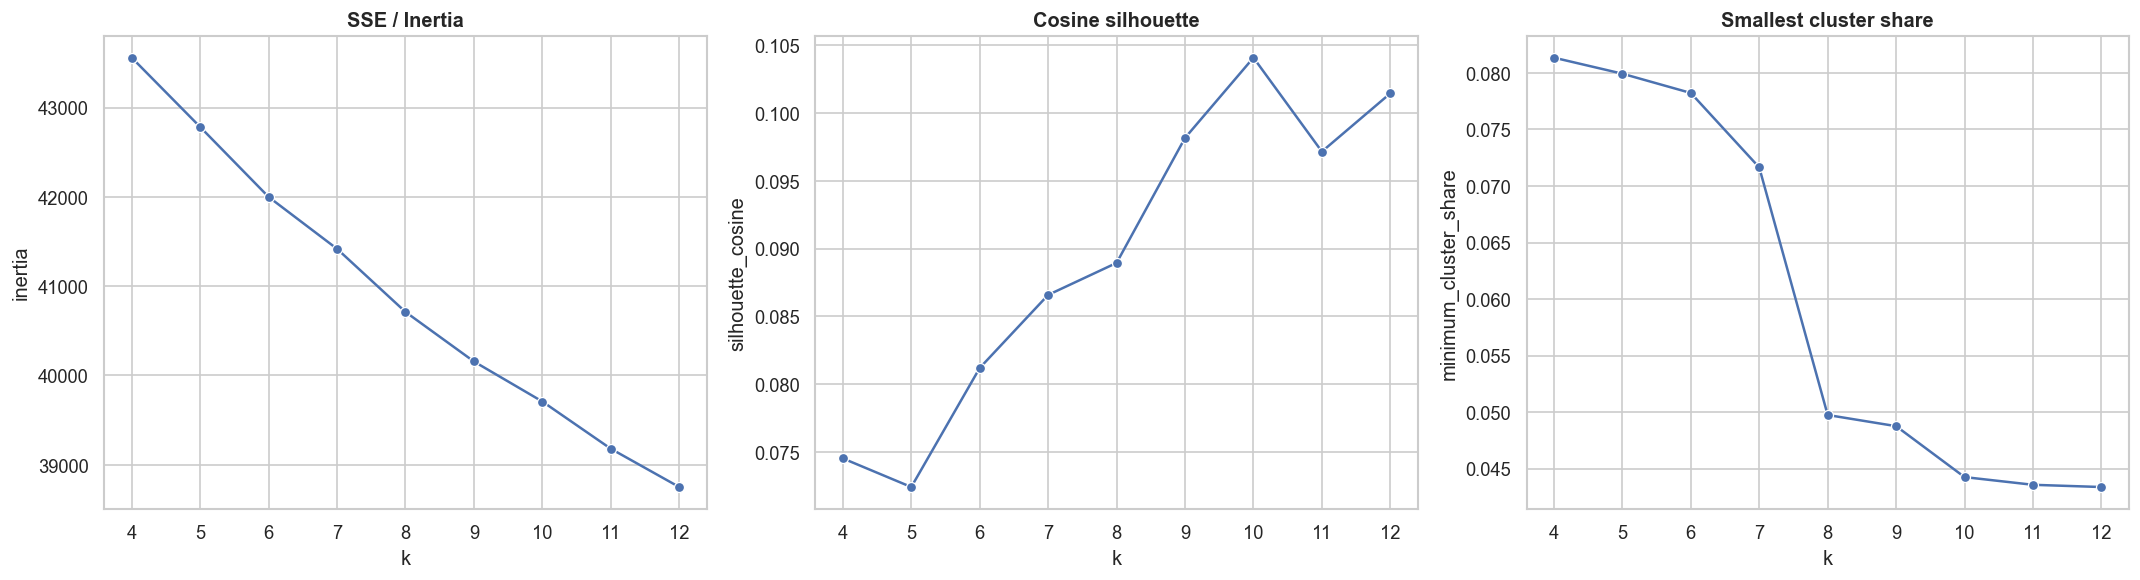

In [5]:
baseline_search_rows = []
search_models = {}

for k in K_VALUES:
    started = time.perf_counter()
    candidate = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        max_iter=300,
        random_state=RANDOM_STATE,
        algorithm="lloyd",
    )
    labels = candidate.fit_predict(X_lsa)
    counts = pd.Series(labels).value_counts(normalize=True)
    sil = silhouette_score(
        X_lsa, labels, metric="cosine",
        sample_size=min(5_000, len(model_df)), random_state=RANDOM_STATE,
    )
    baseline_search_rows.append({
        "k": k,
        "inertia": candidate.inertia_,
        "silhouette_cosine": sil,
        "clusters_found": len(np.unique(labels)),
        "minimum_cluster_share": counts.min(),
        "maximum_cluster_share": counts.max(),
        "seconds": time.perf_counter() - started,
    })
    search_models[k] = candidate
    print(f"Finished k={k}: silhouette={sil:.4f}")

baseline_search_df = pd.DataFrame(baseline_search_rows)
valid_k = baseline_search_df.loc[
    (baseline_search_df["clusters_found"] == baseline_search_df["k"])
    & (baseline_search_df["minimum_cluster_share"] >= 0.02)
]
suggested_baseline_k = int(
    (valid_k if len(valid_k) else baseline_search_df)
    .sort_values(["silhouette_cosine", "k"], ascending=[False, True])
    .iloc[0]["k"]
)
BASELINE_K = int(BASELINE_K_OVERRIDE or suggested_baseline_k)
display(baseline_search_df)
print("Diagnostic suggestion:", suggested_baseline_k)
print("Baseline k used below:", BASELINE_K)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=baseline_search_df, x="k", y="inertia", marker="o", ax=axes[0])
sns.lineplot(data=baseline_search_df, x="k", y="silhouette_cosine", marker="o", ax=axes[1])
sns.lineplot(data=baseline_search_df, x="k", y="minimum_cluster_share", marker="o", ax=axes[2])
axes[0].set_title("SSE / Inertia")
axes[1].set_title("Cosine silhouette")
axes[2].set_title("Smallest cluster share")
plt.tight_layout()
plt.show()

Result guide: A useful k should improve separation without creating collapsed or tiny clusters. The selected value is diagnostic rather than an unquestionable ground truth.

结果说明：合适的k应改善区分度，同时避免坍缩或极小聚类。自动选择只是诊断建议，并非绝对正确答案。

## 6. Fit pure and enhanced K-means baselines / 6. 拟合纯基线与增强K-means基线

Fit K-means++ once on raw TF-IDF and once on TF-IDF plus LSA. Refit the enhanced baseline with more initializations and test seed stability.

分别在原始TF-IDF和TF-IDF加LSA上拟合K-means++。增强基线使用更多初始化重新拟合，并检查随机种子稳定性。

In [6]:
baseline_models = {}
baseline_label_sets = {}
baseline_rows = []

for name, X in [("TF-IDF + KMeans++", X_tfidf), ("TF-IDF + LSA + KMeans++", X_lsa)]:
    started = time.perf_counter()
    fitted = KMeans(
        n_clusters=BASELINE_K,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
        algorithm="lloyd",
    )
    labels = fitted.fit_predict(X)
    sil = silhouette_score(
        X, labels, metric="cosine",
        sample_size=min(5_000, len(model_df)), random_state=RANDOM_STATE,
    )
    baseline_models[name] = fitted
    baseline_label_sets[name] = labels
    baseline_rows.append({
        "method": name,
        "clusters": len(np.unique(labels)),
        "noise_share": 0.0,
        "native_space_silhouette": sil,
        "seconds": time.perf_counter() - started,
    })

baseline_comparison_df = pd.DataFrame(baseline_rows)
display(baseline_comparison_df)

baseline_model = baseline_models["TF-IDF + LSA + KMeans++"]
baseline_labels = baseline_label_sets["TF-IDF + LSA + KMeans++"]
model_df["baseline_cluster"] = baseline_labels

approximate_tfidf_centres = baseline_model.cluster_centers_ @ lsa.components_
baseline_term_rows = []
for cluster_id, centre in enumerate(approximate_tfidf_centres):
    top_indices = centre.argsort()[::-1][:20]
    for rank, feature_index in enumerate(top_indices, start=1):
        baseline_term_rows.append({
            "cluster": cluster_id, "rank": rank,
            "term": feature_names[feature_index], "weight": centre[feature_index],
        })
baseline_terms_df = pd.DataFrame(baseline_term_rows)

baseline_distances = baseline_model.transform(X_lsa)
assigned_baseline_distance = baseline_distances[
    np.arange(len(model_df)), model_df["baseline_cluster"].to_numpy()
]
baseline_representative_rows = []
for cluster_id in range(BASELINE_K):
    positions = np.flatnonzero(model_df["baseline_cluster"].to_numpy() == cluster_id)
    nearest_positions = positions[np.argsort(assigned_baseline_distance[positions])[:8]]
    for rank, row_position in enumerate(nearest_positions, start=1):
        row = model_df.iloc[row_position]
        baseline_representative_rows.append({
            "cluster": cluster_id, "rank": rank,
            "subreddit": row["subreddit"], "post_title": row["post_title"],
            "score": row["score"], "distance_to_centre": assigned_baseline_distance[row_position],
            "text_preview": row["clean_text"][:500],
        })
baseline_representatives_df = pd.DataFrame(baseline_representative_rows)

for cluster_id in range(BASELINE_K):
    print(f"\nBASELINE CLUSTER {cluster_id}")
    print(", ".join(
        baseline_terms_df.loc[baseline_terms_df["cluster"].eq(cluster_id), "term"]
    ))
    display(
        baseline_representatives_df.loc[
            baseline_representatives_df["cluster"].eq(cluster_id),
            ["rank", "subreddit", "post_title", "score", "text_preview"],
        ]
    )

seed_labels = {}
for seed in [42, 52, 62, 72, 82]:
    seed_labels[seed] = KMeans(
        n_clusters=BASELINE_K, init="k-means++", n_init=1,
        max_iter=300, random_state=seed, algorithm="lloyd",
    ).fit_predict(X_lsa)

baseline_stability_df = pd.DataFrame([
    {
        "seed_a": seed_a,
        "seed_b": seed_b,
        "adjusted_rand_index": adjusted_rand_score(seed_labels[seed_a], seed_labels[seed_b]),
    }
    for seed_a, seed_b in combinations(seed_labels, 2)
])
display(baseline_stability_df.describe())

,method,clusters,noise_share,native_space_silhouette,seconds
0,TF-IDF + KMeans++,10,0.0,0.008411,25.578635
1,TF-IDF + LSA + KMeans++,10,0.0,0.102690,2.929263



BASELINE CLUSTER 0
emissions, co2, carbon, not, greenhouse, co2 emissions, gas, climate, carbon emissions, atmosphere, china, greenhouse gas, capture, year, just, no, years, dioxide, carbon dioxide, reduce


,rank,subreddit,post_title,score,text_preview
0,1,climatechange,"What are the best sources of information, sets...",2.0,This is 100% accurate because: 1. The actual c...
1,2,conspiracy,World’s Simplest Argument That Proves Human CO...,2.0,"SS The recent study, Old carbon routed from la..."
2,3,climatechange,Methane... potent but quick,1.0,>I wonder if the potent ghg ability of methane...
3,4,climate,"Planting fast-growing crops, burning them, cap...",9.0,And the fiction just gets more extreme with ev...
4,5,climate,Fuel From Cow Manure Is a Growing Climate Solu...,1.0,"Not true… rather, it’s a lesser-of-two-evils c..."
5,6,climatechange,A Simple Way to Combat Climate Change,2.0,> 97% of CO2 occurs naturally is an undisputed...
6,7,climatechange,Why do flight carbon calculators vary so much?...,2.0,I've experienced this myself. As it comes to c...
7,8,climate,Carbon capture and storage: An evidence-based ...,1.0,I think your point about iron fertilization is...



BASELINE CLUSTER 1
nuclear, power, nuclear power, energy, plants, nuclear energy, plant, cmv, renewables, reactors, not, cmv nuclear, power plants, solar, build, power plant, wind, waste, cost, china


,rank,subreddit,post_title,score,text_preview
8,1,changemyview,"CMV: As a left-winger, we were wrong to oppose...",1.0,">Basically, an equivalent renewable installati..."
9,2,conspiracy,The hostility towards Nuclear Energy is artifi...,0.0,"Nukes are fake, so really makes you wonder abo..."
10,3,Futurology,US firm tests powerful laser to enrich uranium...,1.0,"So, as a layman - how promising is this in ter..."
11,4,Futurology,The US turns back to nuclear power,4.0,Modern nuclear power plants are designed so th...
12,5,climate,Nuclear power could solve US electricity needs...,1.0,I really don't trust the government at this po...
13,6,climatechange,How are we not pushing for more nuclear power?,8.0,This is it - for large CapEx infrastructure fa...
14,7,changemyview,CMV: Nuclear power is a waste of money,1.0,It's not inherently this expensive. What you'r...
15,8,changemyview,"CMV: As a left-winger, we were wrong to oppose...",1.0,Estimated costs according to CSIRO of converti...


...


BASELINE CLUSTER 8
clean, energy, clean energy, trump, china, biden, jobs, projects, new, solar, not, america, just, coal, wind, republicans, power, tax, administration, energy sep


,rank,subreddit,post_title,score,text_preview
64,1,energy,"US clean energy jobs hit 3.56M in 2024, growin...",13.0,Trump is killing our economy in so many ways. ...
65,2,energy,Clean Energy Isn’t a Handout—It’s America’s In...,9.0,Biden hit it out of the park with IIJA and IRA...
66,3,energy,Can clean energy manufacturing survive under T...,-10.0,"""Clean"" energy? Strip Mining, windmill parts i..."
67,4,energy,Clean energy spending boosts GOP districts. Bu...,8.0,Biden’s clean energy push and infrastructure i...
68,5,energy,The Economic Cost of Trump’s Clean Energy Roll...,14.0,All to try and push money into a dying industr...
69,6,energy,Chart: GOP districts to lose big if Trump halt...,2.0,"Hundreds of thousands of people have ""gotten a..."
70,7,energy,Trump will throw US clean power into question....,2.0,Is it clean energy stocks in general or certai...
71,8,energy,"Trump freezes $300bn in clean energy funds, je...",1.0,This will definitely hurt quite a few Red stat...



BASELINE CLUSTER 9
electric, vehicles, electric vehicles, ev, cars, evs, car, cmv electric, battery, not, ice, china, gas, batteries, new, chinese, trump, just, like, cost


,rank,subreddit,post_title,score,text_preview
72,1,energy,Republicans Can Slow but Not Stop Electric Veh...,1.0,What in the world is this comment going on abo...
73,2,energy,US Automakers Risk Being Reduced to Niche Prod...,6.0,Eventually the US will come around because any...
74,3,climate,Electric vehicles will end oil wars - if we le...,1.0,Well some of these new EVs are discovering new...
75,4,changemyview,CMV: Electric Vehicles aren't as bad as people...,1.0,I like EVs myself and the idea of owning one. ...
76,5,changemyview,CMV: Electric vehicles (EVs) are overall good ...,2.0,I own a fully electric car and a plug-in hybri...
77,6,energy,Republicans Can Slow but Not Stop Electric Veh...,1.0,In markets that have carbon cap and trade syst...
78,7,changemyview,CMV: Electric Vehicles aren't as bad as people...,2.0,"I'm not sure right now, but I believe the elec..."
79,8,energy,Electric vehicles and hybrids grow to a record...,0.0,"Maintenance is proven more expensive on EVs, s..."


,seed_a,seed_b,adjusted_rand_index
count,10.000000,10.000000,10.000000
mean,52.000000,72.000000,0.706335
std,10.540926,10.540926,0.162648
min,42.000000,52.000000,0.512693
25%,42.000000,64.500000,0.565280
50%,52.000000,72.000000,0.662896
75%,59.500000,82.000000,0.844916
max,72.000000,82.000000,0.991758


Result guide: This separates the course-style TF-IDF baseline from the LSA-enhanced version. Higher ARI means the solution is less dependent on initialization. Terms and representative comments provide the baseline interpretation evidence.

结果说明：这里把课程式TF-IDF基线与LSA增强版本分开。ARI越高，结果越不依赖初始化。关键词和代表性评论提供解释基线主题的证据。

## 7. Ward and DBSCAN course diagnostics / 7. Ward与DBSCAN课程诊断

Run hierarchical Ward clustering and DBSCAN on the same fixed smaller sample. This respects their memory and high-dimensional limitations while still testing the course concepts.

在同一个固定小样本上运行Ward层次聚类和DBSCAN，在尊重其内存及高维限制的同时检验课程方法。

In [7]:
course_parts = []
for subreddit in SELECTED_SUBREDDITS:
    group = model_df.loc[model_df["subreddit"].eq(subreddit)]
    course_parts.append(group.sample(
        n=min(COURSE_SAMPLE_PER_SUBREDDIT, len(group)),
        random_state=RANDOM_STATE,
    ))
course_df = pd.concat(course_parts).sort_index()
course_positions = course_df.index.to_numpy()
X_course = X_lsa[course_positions]

ward_model = AgglomerativeClustering(n_clusters=BASELINE_K, linkage="ward")
ward_labels = ward_model.fit_predict(X_course)

min_pts = 10
neighbor_model = NearestNeighbors(n_neighbors=min_pts, metric="euclidean").fit(X_course)
neighbor_distances, _ = neighbor_model.kneighbors(X_course)
k_distances = neighbor_distances[:, -1]
eps_values = np.unique(np.quantile(k_distances, [0.70, 0.80, 0.85, 0.90, 0.95]))

dbscan_rows = []
dbscan_models = {}
for eps in eps_values:
    fitted = DBSCAN(eps=float(eps), min_samples=min_pts, metric="euclidean", n_jobs=-1)
    labels = fitted.fit_predict(X_course)
    assigned = labels >= 0
    n_clusters = len(set(labels[assigned]))
    coverage = assigned.mean()
    if n_clusters >= 2 and assigned.sum() > n_clusters:
        sil = silhouette_score(
            X_course[assigned], labels[assigned], metric="cosine",
            sample_size=min(2_000, assigned.sum()), random_state=RANDOM_STATE,
        )
    else:
        sil = np.nan
    score = (0 if np.isnan(sil) else sil) * coverage
    dbscan_rows.append({
        "eps": float(eps), "min_samples": min_pts,
        "clusters": n_clusters, "coverage": coverage,
        "noise_share": 1 - coverage, "silhouette_non_noise": sil,
        "coverage_weighted_score": score,
    })
    dbscan_models[float(eps)] = (fitted, labels)

dbscan_search_df = pd.DataFrame(dbscan_rows)
valid_dbscan = dbscan_search_df.loc[dbscan_search_df["clusters"].between(2, 30)]
chosen_dbscan_row = (
    valid_dbscan if len(valid_dbscan) else dbscan_search_df
).sort_values("coverage_weighted_score", ascending=False).iloc[0]
chosen_eps = float(chosen_dbscan_row["eps"])
dbscan_model, dbscan_labels = dbscan_models[chosen_eps]

course_df = course_df.copy()
course_df["ward_cluster"] = ward_labels
course_df["dbscan_cluster"] = dbscan_labels

course_metrics_df = pd.DataFrame([
    {
        "method": "Ward hierarchical",
        "clusters": len(np.unique(ward_labels)),
        "noise_share": 0.0,
        "silhouette": silhouette_score(X_course, ward_labels, metric="cosine"),
    },
    {
        "method": "DBSCAN",
        "clusters": int(chosen_dbscan_row["clusters"]),
        "noise_share": float(chosen_dbscan_row["noise_share"]),
        "silhouette": float(chosen_dbscan_row["silhouette_non_noise"]),
    },
])
display(dbscan_search_df)
display(course_metrics_df)

,eps,min_samples,clusters,coverage,noise_share,silhouette_non_noise,coverage_weighted_score
0,0.943304,10,2,0.926000,0.074000,0.121806,0.112793
1,0.968571,10,2,0.955667,0.044333,0.125684,0.120112
2,0.985766,10,2,0.967333,0.032667,0.117902,0.114051
3,1.009085,10,2,0.977000,0.023000,0.116311,0.113636
4,1.048915,10,1,0.988333,0.011667,NaN,0.000000


,method,clusters,noise_share,silhouette
0,Ward hierarchical,10,0.000000,0.029612
1,DBSCAN,2,0.044333,0.125684


Result guide: Ward forces every sampled comment into a fixed number of clusters. DBSCAN can mark comments as noise; an extreme noise rate or one giant cluster demonstrates the course warning about density methods in text spaces.

结果说明：Ward会把每条抽样评论分到固定数量的类别。DBSCAN可以标记噪声；极高噪声率或单一巨大聚类会体现课程中关于高维文本密度方法的警告。

## 8. Visualize the course diagnostics / 8. 可视化课程诊断

Plot a Ward dendrogram on a readable subsample and show DBSCAN labels in a two-dimensional projection.

在可阅读的小样本上绘制Ward树状图，并在二维投影中展示DBSCAN标签。

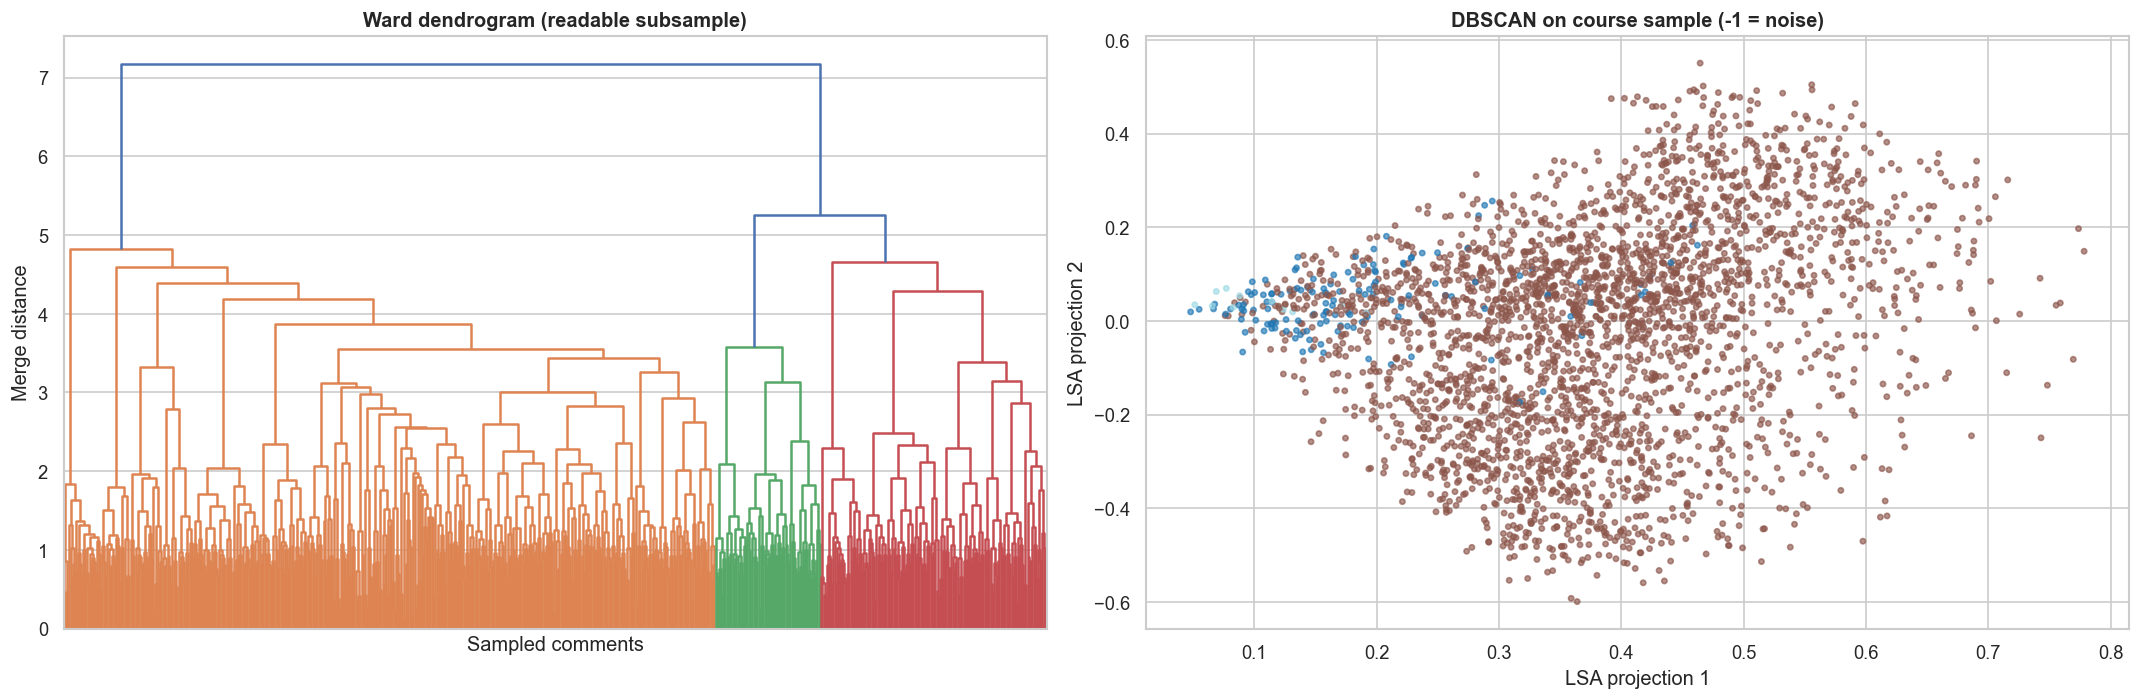

In [8]:
dendrogram_size = min(800, len(course_df))
dendrogram_positions = np.random.default_rng(RANDOM_STATE).choice(
    len(course_df), size=dendrogram_size, replace=False
)
Z = linkage(X_course[dendrogram_positions], method="ward")

projection = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(X_course)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
dendrogram(Z, no_labels=True, color_threshold=None, ax=axes[0])
axes[0].set_title("Ward dendrogram (readable subsample)")
axes[0].set_xlabel("Sampled comments")
axes[0].set_ylabel("Merge distance")

scatter = axes[1].scatter(
    projection[:, 0], projection[:, 1],
    c=dbscan_labels, cmap="tab20", s=10, alpha=0.65,
)
axes[1].set_title("DBSCAN on course sample (-1 = noise)")
axes[1].set_xlabel("LSA projection 1")
axes[1].set_ylabel("LSA projection 2")
plt.tight_layout()
plt.show()

Result guide: Long vertical jumps in the dendrogram suggest possible cut levels. The DBSCAN plot shows whether density groups are separated or dominated by noise and chaining.

结果说明：树状图中的较长垂直跳跃提示可能的切割层级。DBSCAN图显示密度聚类是否分离，或是否被噪声和链式连接主导。

## 9. Create semantic embeddings / 9. 创建语义向量

Encode the same modeling sample with an open-source Sentence Transformer. The cache prevents repeated encoding when the notebook is rerun.

使用开源Sentence Transformer编码同一建模样本。缓存可以避免每次重新运行时重复计算。

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
sentence_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=device)
embedding_cache_path = CACHE_DIR / f"training_embeddings_{len(model_df)}.npy"

if embedding_cache_path.exists():
    X_embeddings = np.load(embedding_cache_path)
    print("Loaded cached embeddings:", embedding_cache_path)
else:
    started = time.perf_counter()
    X_embeddings = sentence_model.encode(
        model_df["model_text"].tolist(),
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    np.save(embedding_cache_path, X_embeddings)
    print("Embedding time:", f"{time.perf_counter() - started:.1f} seconds")

print("Semantic embedding shape:", X_embeddings.shape)
print("Embedding model:", EMBEDDING_MODEL_NAME)
print("Device:", device)

d:\python 3.13.7\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tqw\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
d:\python 3.13.7\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-syste

Embedding time: 204.8 seconds
Semantic embedding shape: (55722, 384)
Embedding model: sentence-transformers/all-MiniLM-L6-v2
Device: cpu


Result guide: The output should contain one normalized semantic vector per modeling comment. Loading the cache is expected on later runs.

结果说明：输出应为每条建模评论生成一个归一化语义向量。后续重跑时读取缓存属于正常现象。

## 10. UMAP and HDBSCAN parameter search / 10. UMAP与HDBSCAN参数搜索

Reduce the semantic vectors once with UMAP, then compare several HDBSCAN density settings. HDBSCAN chooses the number of clusters and can retain uncertain comments as noise.

先用UMAP对语义向量降维，再比较多组HDBSCAN密度参数。HDBSCAN自行决定聚类数量，并可把不确定评论保留为噪声。

In [10]:
print("Loading UMAP. The first import on Python 3.13 may take several minutes while Numba compiles.")
import umap

umap_model = umap.UMAP(
    n_neighbors=UMAP_NEIGHBORS,
    n_components=UMAP_COMPONENTS,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
    low_memory=True,
)
started = time.perf_counter()
X_umap = umap_model.fit_transform(X_embeddings).astype(np.float32)
print("UMAP shape:", X_umap.shape)
print("UMAP time:", f"{time.perf_counter() - started:.1f} seconds")

advanced_rows = []
advanced_candidates = {}
for min_cluster_size in HDBSCAN_MIN_CLUSTER_SIZES:
    for min_samples in HDBSCAN_MIN_SAMPLES:
        started = time.perf_counter()
        candidate = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True,
            gen_min_span_tree=True,
            core_dist_n_jobs=-1,
        )
        labels = candidate.fit_predict(X_umap)
        assigned = labels >= 0
        n_clusters = len(set(labels[assigned]))
        coverage = assigned.mean()
        if n_clusters >= 2 and assigned.sum() > n_clusters:
            assigned_positions = np.flatnonzero(assigned)
            eval_positions = np.random.default_rng(RANDOM_STATE).choice(
                assigned_positions,
                size=min(5_000, len(assigned_positions)),
                replace=False,
            )
            semantic_silhouette = silhouette_score(
                X_embeddings[eval_positions], labels[eval_positions], metric="cosine"
            )
        else:
            semantic_silhouette = np.nan
        relative_validity = float(candidate.relative_validity_)
        selection_score = coverage * (
            max(relative_validity, 0) + max(semantic_silhouette if not np.isnan(semantic_silhouette) else 0, 0)
        )
        key = (min_cluster_size, min_samples)
        advanced_candidates[key] = (candidate, labels)
        advanced_rows.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "coverage": coverage,
            "noise_share": 1 - coverage,
            "relative_validity": relative_validity,
            "semantic_silhouette_non_noise": semantic_silhouette,
            "selection_score": selection_score,
            "seconds": time.perf_counter() - started,
        })
        print(key, "clusters=", n_clusters, "coverage=", f"{coverage:.1%}")

advanced_search_df = pd.DataFrame(advanced_rows)
valid_advanced = advanced_search_df.loc[
    advanced_search_df["clusters"].between(4, 40)
    & advanced_search_df["coverage"].ge(0.50)
]
selection_pool = valid_advanced if len(valid_advanced) else advanced_search_df.loc[
    advanced_search_df["clusters"].ge(2)
]

if ADVANCED_PARAMETER_OVERRIDE is None:
    selected_row = selection_pool.sort_values("selection_score", ascending=False).iloc[0]
    selected_parameters = (
        int(selected_row["min_cluster_size"]), int(selected_row["min_samples"])
    )
else:
    selected_parameters = tuple(ADVANCED_PARAMETER_OVERRIDE)

advanced_model, advanced_labels = advanced_candidates[selected_parameters]
model_df["advanced_cluster"] = advanced_labels
model_df["advanced_membership_strength"] = advanced_model.probabilities_
display(advanced_search_df)
print("Selected parameters:", selected_parameters)
print("Selected clusters:", len(set(advanced_labels[advanced_labels >= 0])))
print("Noise share:", f"{(advanced_labels < 0).mean():.2%}")

Loading UMAP. The first import on Python 3.13 may take several minutes while Numba compiles.


d:\python 3.13.7\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (55722, 10)
UMAP time: 49.9 seconds
(300, 10) clusters= 32 coverage= 52.8%
(300, 30) clusters= 30 coverage= 51.0%
(600, 10) clusters= 2 coverage= 97.9%
(600, 30) clusters= 2 coverage= 96.1%
(1200, 10) clusters= 8 coverage= 58.0%
(1200, 30) clusters= 9 coverage= 58.5%


,min_cluster_size,min_samples,clusters,coverage,noise_share,relative_validity,semantic_silhouette_non_noise,selection_score,seconds
0,300,10,32,0.527924,0.472076,0.164686,0.089839,0.134370,4.542857
1,300,30,30,0.509906,0.490094,0.240696,0.083986,0.165557,2.405133
2,600,10,2,0.978805,0.021195,0.004335,0.126642,0.128201,2.118563
3,600,30,2,0.961254,0.038746,0.022897,0.153846,0.169896,2.296275
4,1200,10,8,0.579663,0.420337,0.112898,0.058075,0.099107,2.103488
5,1200,30,9,0.584850,0.415150,0.186889,0.065547,0.147637,2.205970


Selected parameters: (300, 30)
Selected clusters: 30
Noise share: 49.01%


Result guide: A useful setting should create interpretable clusters without labeling most documents as noise. The selected result remains subject to topic inspection.

结果说明：合适的设置应生成可解释聚类，同时不能把大多数文本标记为噪声。最终选择仍需结合主题内容检查。

## 11. Describe advanced topics with c-TF-IDF / 11. 使用c-TF-IDF描述高级主题

Aggregate documents by HDBSCAN cluster, calculate class-based TF-IDF, and retrieve representative comments nearest to each semantic centroid.

按HDBSCAN聚类合并文本，计算类别级TF-IDF，并提取最接近各语义中心的代表性评论。

In [11]:
def build_ctfidf_topics(frame, label_column, top_n=20):
    assigned = frame.loc[frame[label_column].ge(0), [label_column, "model_text"]].copy()
    grouped = assigned.groupby(label_column)["model_text"].agg(" ".join).sort_index()
    topic_vectorizer = CountVectorizer(
        stop_words=custom_stop_words,
        ngram_range=(1, 2),
        min_df=1,
        max_features=50_000,
    )
    counts = topic_vectorizer.fit_transform(grouped)
    class_tf = normalize(counts, norm="l1", axis=1)
    document_frequency = np.asarray((counts > 0).sum(axis=0)).ravel()
    average_words = float(np.asarray(counts.sum(axis=1)).mean())
    idf = np.log1p(average_words / np.maximum(document_frequency, 1))
    ctfidf = class_tf @ diags(idf)
    terms = topic_vectorizer.get_feature_names_out()

    rows = []
    for row_position, cluster_id in enumerate(grouped.index):
        weights = ctfidf.getrow(row_position).toarray().ravel()
        top_indices = weights.argsort()[::-1][:top_n]
        for rank, term_index in enumerate(top_indices, start=1):
            rows.append({
                "cluster": int(cluster_id), "rank": rank,
                "term": terms[term_index], "weight": weights[term_index],
            })
    return pd.DataFrame(rows), topic_vectorizer, ctfidf


advanced_terms_df, ctfidf_vectorizer, advanced_ctfidf = build_ctfidf_topics(
    model_df, "advanced_cluster", top_n=20
)

representative_rows = []
for cluster_id in sorted(model_df.loc[model_df["advanced_cluster"].ge(0), "advanced_cluster"].unique()):
    positions = np.flatnonzero(model_df["advanced_cluster"].to_numpy() == cluster_id)
    centroid = X_embeddings[positions].mean(axis=0)
    centroid /= np.linalg.norm(centroid) + 1e-12
    similarities = X_embeddings[positions] @ centroid
    nearest_local = np.argsort(similarities)[::-1][:8]
    for rank, local_position in enumerate(nearest_local, start=1):
        row_position = positions[local_position]
        row = model_df.iloc[row_position]
        representative_rows.append({
            "cluster": int(cluster_id), "rank": rank,
            "subreddit": row["subreddit"], "post_title": row["post_title"],
            "score": row["score"], "membership_strength": row["advanced_membership_strength"],
            "semantic_similarity": similarities[local_position],
            "text_preview": row["clean_text"][:500],
        })

advanced_representatives_df = pd.DataFrame(representative_rows)
for cluster_id in sorted(advanced_terms_df["cluster"].unique()):
    print(f"\nADVANCED CLUSTER {cluster_id}")
    print(", ".join(
        advanced_terms_df.loc[advanced_terms_df["cluster"].eq(cluster_id), "term"]
    ))
    display(
        advanced_representatives_df.loc[
            advanced_representatives_df["cluster"].eq(cluster_id),
            ["rank", "subreddit", "post_title", "membership_strength", "text_preview"],
        ]
    )


ADVANCED CLUSTER 0
climate, sep, people, political, not, cmv, political climate, current political, current, like, change, right, trump, just, climate change, no, fight, 15 minute, fight climate, voting


,rank,subreddit,post_title,membership_strength,text_preview
0,1,changemyview,CMV: The current political climate is only the...,1.0,As a woman observing America from the outside ...
1,2,changemyview,CMV: The current political climate is only the...,1.0,Because it hasnt been challenged at all thus f...
2,3,changemyview,CMV: The American people are to blame for the ...,1.0,because its assuming that others adopting an i...
3,4,changemyview,CMV: The current political climate is only the...,1.0,"In my opinion, the monumental shift is what is..."
4,5,changemyview,CMV: The American people are to blame for the ...,1.0,You are exactly right. So few people recognize...
5,6,changemyview,CMV: The American people are to blame for the ...,1.0,I agree. A corollary to my view is that no one...
6,7,changemyview,"CMV: The 70s, 80s and 90s were generally bette...",1.0,Climate change has been an ever-increasing thr...
7,8,changemyview,CMV: The current political climate is only the...,1.0,I personally see it as a 2 steps back 1 step f...



ADVANCED CLUSTER 1
not, sep, just, feminism, cmv, climate, people, birthrates, carbon, change, war climate, war, humanity, climate change, nuclear war, like, women, birth, nuclear, feminism biggest


,rank,subreddit,post_title,membership_strength,text_preview
8,1,changemyview,CMV: Birthrates should be seen as a matter of ...,1.0,"This isnt an issue of ""if"" women have to suffe..."
9,2,changemyview,CMV: Feminism might be the biggest threat to h...,1.0,If population decline actually starts to becom...
10,3,changemyview,CMV: Feminism might be the biggest threat to h...,1.0,The biggest contributor to the declining birth...
11,4,changemyview,CMV: Birthrates should be seen as a matter of ...,1.0,"Ideally, there would be a manageable decline o..."
12,5,changemyview,CMV: Birthrates should be seen as a matter of ...,1.0,>If that's the best we've come up with after a...
13,6,changemyview,CMV: Birthrates should be seen as a matter of ...,1.0,We’re not even declining yet. Human population...
14,7,changemyview,CMV: Birthrates should be seen as a matter of ...,1.0,Part of it is that women have more choice than...
15,8,changemyview,CMV: Birthrates should be seen as a matter of ...,1.0,>The rest of the world is also approaching or ...



ADVANCED CLUSTER 2
sep, climate, change, climate change, earth, like, scientific, flat, flat earth, scientific misinformation, public platforms, like flat, misinformation, earth theory, cmv scientific, denial restricted, restricted public, not, people, reject man


...

,rank,subreddit,post_title,membership_strength,text_preview
216,1,conspiracy,Climate predictions continue to fail. Liars a...,1.0,Because there is overwhelming data that suppor...
217,2,conspiracy,Climate predictions continue to fail. Liars a...,1.0,No straw man. He said they state it's not real...
218,3,changemyview,"CMV: despite being scientifically true, much o...",1.0,"I'm confused about your view, all through this..."
219,4,conspiracy,Climate predictions continue to fail. Liars a...,1.0,You aren't talking about conspiracy. You're ta...
220,5,conspiracy,Climate predictions continue to fail. Liars a...,1.0,While I agree with you that climate change is ...
221,6,conspiracy,Climate predictions continue to fail. Liars a...,1.0,I don't disagree. The argument isn't who fixes...
222,7,conspiracy,Climate predictions continue to fail. Liars a...,1.0,Climate does change. We don’t fully know why o...
223,8,conspiracy,What is your conspiracy theory about climate c...,1.0,The real scammers are the people who want you ...



ADVANCED CLUSTER 28
co2, sep, not, earth, climate, years, atmosphere, temperature, carbon, change, levels, sun, atmospheric, increase, warming, ppm, time, co2 levels, climate change, human


,rank,subreddit,post_title,membership_strength,text_preview
224,1,conspiracy,Humans are not causing atmospheric CO2 levels ...,1.0,It doesn’t exactly take a super genius to real...
225,2,conspiracy,Humans are not causing atmospheric CO2 levels ...,1.0,Once extreme weather events become the norm (i...
226,3,conspiracy,Humans are not causing atmospheric CO2 levels ...,1.0,"Well said, and I know you're right, it just pa..."
227,4,conspiracy,Today’s climate lies and alarmist propaganda p...,1.0,>Educate us!!!! We have observed the global av...
228,5,conspiracy,Humans are not causing atmospheric CO2 levels ...,1.0,No. The earth is reflecting less sunlight back...
229,6,energy,Climate summit leader said there’s ‘no science...,1.0,Plants & animals thrived at 10x CO2 levels but...
230,7,conspiracy,Humans are not causing atmospheric CO2 levels ...,1.0,It was yes. But the earth was less habitable f...
231,8,conspiracy,Humans are not causing atmospheric CO2 levels ...,1.0,"That's also not that hard, if you want to argu..."



ADVANCED CLUSTER 29
sep, climate, warming, global, not, 5c, year, temperature, world, years, global warming, earth, just, average, change, 2024, scientists, el, record, temperatures


,rank,subreddit,post_title,membership_strength,text_preview
232,1,climate,Is it too late to keep global warmingbelow 1.5...,1.000000,This 20 year measurement standard is moot. We ...
233,2,climatechange,World ‘very likely’ to exceed 1.5C climate goa...,1.000000,"""Earth breaches 1.5 °C climate limit for the f..."
234,3,climate,World’s top climate scientists expect global h...,1.000000,This has been obvious for a while. While the r...
235,4,climate,Is it too late to keep global warmingbelow 1.5...,1.000000,Growth in concentration hasn't slowed; what's ...
236,5,conspiracy,Global Warming Reached +1.53°C in 2024,0.991105,Submission statement: It's clear by now that n...
237,6,conspiracy,60 years of Failed Climate Change prediction. ...,0.910694,So you plan to live for the next century? You ...
238,7,Futurology,Newly released paper suggests that global warm...,1.000000,2-3 is already more than enough to collapse hu...
239,8,climatechange,Sea sponge study suggests Earth has already su...,0.827402,I have little faith in the IPCC given it's lar...


Result guide: Each topic must be named only after reviewing both its c-TF-IDF terms and representative comments. Generic or mixed topics indicate that parameters or relevance rules still need revision.

结果说明：每个主题都必须同时检查c-TF-IDF关键词和代表性评论后再命名。泛化或混合主题意味着参数或相关性规则仍需调整。

## 12. Compare baseline and advanced methods fairly / 12. 公平比较基线与高级方法

Evaluate both label sets in the same semantic embedding space, and report advanced coverage, baseline seed stability, and agreement between neighboring HDBSCAN settings.

在同一个语义向量空间评价两套标签，并报告高级方法覆盖率、基线随机种子稳定性及相邻HDBSCAN设置的一致性。

,method,clusters,coverage,semantic_space_silhouette,stability_ari_median
0,Course baseline: TF-IDF + KMeans++,10,1.000000,-0.019692,NaN
1,Enhanced baseline: TF-IDF + LSA + KMeans++,10,1.000000,-0.002064,0.662896
2,Advanced: SBERT + UMAP + HDBSCAN,30,0.509906,0.083986,0.006094


,parameters_a,parameters_b,common_assigned,adjusted_rand_index
count,15,15,15.000000,15.000000
unique,5,5,NaN,NaN
top,"(300, 10)","(1200, 30)",NaN,NaN
freq,5,5,NaN,NaN
mean,NaN,NaN,30140.266667,0.307584
std,NaN,NaN,7271.815262,0.386067
min,NaN,NaN,23311.000000,0.000000
25%,NaN,NaN,25639.000000,0.002661
50%,NaN,NaN,29309.000000,0.006094
75%,NaN,NaN,32300.000000,0.464622


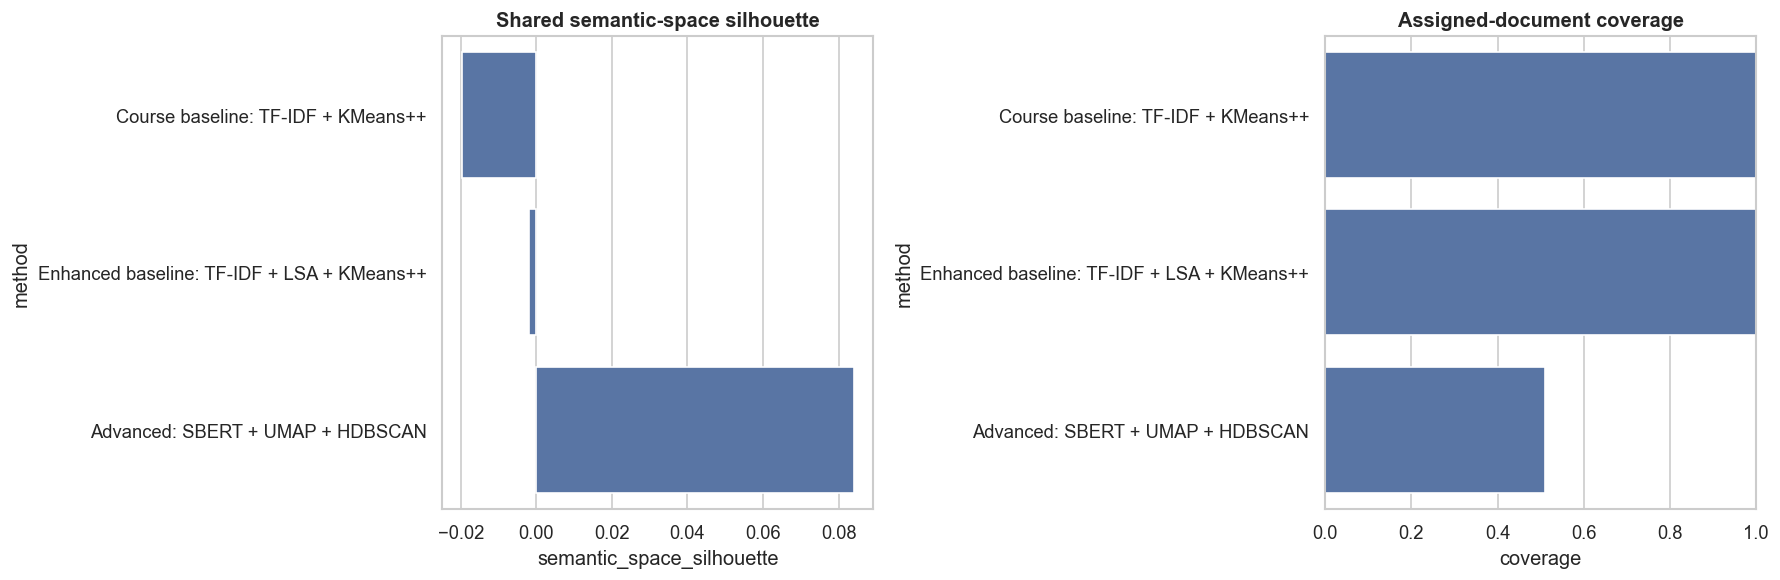

In [12]:
def shared_semantic_silhouette(embeddings, labels, random_state=RANDOM_STATE):
    labels = np.asarray(labels)
    assigned = labels >= 0
    unique_labels = np.unique(labels[assigned])
    if len(unique_labels) < 2:
        return np.nan
    positions = np.flatnonzero(assigned)
    eval_positions = np.random.default_rng(random_state).choice(
        positions, size=min(5_000, len(positions)), replace=False
    )
    return silhouette_score(
        embeddings[eval_positions], labels[eval_positions], metric="cosine"
    )


advanced_pairwise_rows = []
for key_a, key_b in combinations(advanced_candidates, 2):
    labels_a = advanced_candidates[key_a][1]
    labels_b = advanced_candidates[key_b][1]
    common = (labels_a >= 0) & (labels_b >= 0)
    ari = adjusted_rand_score(labels_a[common], labels_b[common]) if common.sum() else np.nan
    advanced_pairwise_rows.append({
        "parameters_a": str(key_a), "parameters_b": str(key_b),
        "common_assigned": int(common.sum()), "adjusted_rand_index": ari,
    })
advanced_stability_df = pd.DataFrame(advanced_pairwise_rows)

comparison_df = pd.DataFrame([
    {
        "method": "Course baseline: TF-IDF + KMeans++",
        "clusters": len(np.unique(baseline_label_sets["TF-IDF + KMeans++"])),
        "coverage": 1.0,
        "semantic_space_silhouette": shared_semantic_silhouette(
            X_embeddings, baseline_label_sets["TF-IDF + KMeans++"]
        ),
        "stability_ari_median": np.nan,
    },
    {
        "method": "Enhanced baseline: TF-IDF + LSA + KMeans++",
        "clusters": len(np.unique(baseline_labels)),
        "coverage": 1.0,
        "semantic_space_silhouette": shared_semantic_silhouette(X_embeddings, baseline_labels),
        "stability_ari_median": baseline_stability_df["adjusted_rand_index"].median(),
    },
    {
        "method": "Advanced: SBERT + UMAP + HDBSCAN",
        "clusters": len(set(advanced_labels[advanced_labels >= 0])),
        "coverage": float((advanced_labels >= 0).mean()),
        "semantic_space_silhouette": shared_semantic_silhouette(X_embeddings, advanced_labels),
        "stability_ari_median": advanced_stability_df["adjusted_rand_index"].median(),
    },
])
display(comparison_df)
display(advanced_stability_df.describe(include="all"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=comparison_df, y="method", x="semantic_space_silhouette", ax=axes[0])
sns.barplot(data=comparison_df, y="method", x="coverage", ax=axes[1])
axes[0].set_title("Shared semantic-space silhouette")
axes[1].set_title("Assigned-document coverage")
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

Result guide: The advanced method is not automatically better. It should improve semantic separation and topic clarity while retaining an acceptable proportion of documents and reasonable stability.

结果说明：高级方法并不自动更好。它应在保持可接受文本覆盖率和合理稳定性的同时，提高语义分离和主题清晰度。

## 13. Assign both main models to the full eligible corpus / 13. 将两种主要模型应用于全部合格语料

Transform the full eligible corpus in chunks. K-means assigns every comment; HDBSCAN can return -1 for comments that do not confidently belong to a learned topic.

分块转换全部合格语料。K-means会分配每条评论；HDBSCAN可把不能可靠归入已学习主题的评论标为-1。

In [13]:
if ASSIGN_FULL_CORPUS:
    all_baseline_labels = np.empty(len(analysis_df), dtype=np.int32)
    all_advanced_labels = np.empty(len(analysis_df), dtype=np.int32)
    all_advanced_strengths = np.empty(len(analysis_df), dtype=np.float32)

    for start in range(0, len(analysis_df), FULL_ASSIGNMENT_CHUNK_SIZE):
        stop = min(start + FULL_ASSIGNMENT_CHUNK_SIZE, len(analysis_df))
        texts = analysis_df.loc[start:stop - 1, "model_text"].tolist()

        chunk_tfidf = vectorizer.transform(texts)
        chunk_lsa = normalizer.transform(lsa.transform(chunk_tfidf)).astype(np.float32)
        all_baseline_labels[start:stop] = baseline_model.predict(chunk_lsa)

        chunk_embeddings = sentence_model.encode(
            texts,
            batch_size=EMBEDDING_BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        ).astype(np.float32)
        chunk_umap = umap_model.transform(chunk_embeddings).astype(np.float32)
        predicted_labels, predicted_strengths = approximate_predict(advanced_model, chunk_umap)
        all_advanced_labels[start:stop] = predicted_labels
        all_advanced_strengths[start:stop] = predicted_strengths
        print(f"Assigned {stop:,} / {len(analysis_df):,}")

    analysis_df["baseline_cluster"] = all_baseline_labels
    analysis_df["advanced_cluster"] = all_advanced_labels
    analysis_df["advanced_membership_strength"] = all_advanced_strengths
else:
    print("Full assignment skipped. Set ASSIGN_FULL_CORPUS=True to produce final RQ2 tables.")

Assigned 20,000 / 330,273
Assigned 40,000 / 330,273
Assigned 60,000 / 330,273
Assigned 80,000 / 330,273
Assigned 100,000 / 330,273
Assigned 120,000 / 330,273
Assigned 140,000 / 330,273
Assigned 160,000 / 330,273
Assigned 180,000 / 330,273
Assigned 200,000 / 330,273
Assigned 220,000 / 330,273
Assigned 240,000 / 330,273
Assigned 260,000 / 330,273
Assigned 280,000 / 330,273
Assigned 300,000 / 330,273
Assigned 320,000 / 330,273
Assigned 330,273 / 330,273


Result guide: Completion messages should reach the full corpus size. Advanced cluster -1 is intentional noise rather than an execution error.

结果说明：完成信息应到达全部语料数量。高级聚类中的-1表示有意保留的噪声，而不是运行错误。

## 14. RQ1 topic summaries / 14. RQ1主题汇总

Summarize the number of comments, posts, users, length, engagement, and controversy for each advanced topic. Noise is reported separately.

按高级主题汇总评论数、帖子数、用户数、长度、互动和争议度，并单独报告噪声。

In [14]:
if ASSIGN_FULL_CORPUS:
    advanced_cluster_summary = (
        analysis_df.groupby("advanced_cluster", observed=True)
        .agg(
            comments=("comment_id", "size"),
            posts=("post_id", "nunique"),
            authors=("author_name", "nunique"),
            median_words=("comment_word_count", "median"),
            median_score=("score", "median"),
            controversial_rate=("controversiality", "mean"),
            median_membership_strength=("advanced_membership_strength", "median"),
        )
        .reset_index()
    )
    advanced_cluster_summary["comment_share"] = (
        advanced_cluster_summary["comments"] / len(analysis_df)
    )
    display(advanced_cluster_summary)

    baseline_cluster_summary = (
        analysis_df.groupby("baseline_cluster", observed=True)
        .agg(comments=("comment_id", "size"), posts=("post_id", "nunique"))
        .reset_index()
    )
    baseline_cluster_summary["comment_share"] = baseline_cluster_summary["comments"] / len(analysis_df)
    display(baseline_cluster_summary)

,advanced_cluster,comments,posts,authors,median_words,median_score,controversial_rate,median_membership_strength,comment_share
0,-1,163539,13302,46806,45.0,2.0,0.030103,0.000000,0.495163
1,0,1018,61,612,60.0,1.0,0.057957,1.000000,0.003082
2,1,777,65,426,53.0,2.0,0.047619,1.000000,0.002353
3,2,788,209,539,45.0,1.0,0.109137,1.000000,0.002386
4,3,2650,416,1890,47.0,2.0,0.058868,1.000000,0.008024
5,4,1554,264,910,50.0,2.0,0.075290,1.000000,0.004705
6,5,16961,1300,8238,45.0,2.0,0.028831,0.585560,0.051354
7,6,2528,636,1495,46.0,2.0,0.018196,1.000000,0.007654
8,7,6654,808,2854,49.0,2.0,0.074992,0.858910,0.020147
9,8,2542,371,1165,48.0,2.0,0.041699,1.000000,0.007697


,baseline_cluster,comments,posts,comment_share
0,0,35649,5271,0.107938
1,1,10447,1144,0.031631
2,2,68681,7335,0.207952
3,3,60043,6063,0.181798
4,4,17810,3044,0.053925
5,5,28382,5205,0.085935
6,6,29865,3961,0.090425
7,7,43789,6587,0.132584
8,8,20954,2093,0.063444
9,9,14653,1341,0.044366


Result guide: The final topic names should be added only after inspecting terms, representative comments, cluster size, and membership strength together.

结果说明：最终主题名称应在综合检查关键词、代表性评论、聚类规模和成员强度后再添加。

## 15. RQ2 community-topic comparison / 15. RQ2社区—主题比较

Compare advanced topic distributions across the six communities and quantify association using chi-square, Cramer's V, and standardized residuals.

比较六个社区的高级主题分布，并用卡方检验、Cramer's V和标准化残差量化关联。

,noise_rate
subreddit,
climatechange,0.580601
climate,0.503625
energy,0.317025
Futurology,0.481151
conspiracy,0.645796
changemyview,0.413917


advanced_cluster,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
subreddit,,,,,,,,,,,,,,,,,,,,,
climatechange,38,99,268,703,105,2304,1166,1759,357,986,...,2941,2198,1609,1305,2368,73,2728,2395,3970,3839
climate,14,88,69,1307,953,1894,905,4122,100,1325,...,2892,345,1709,828,1524,35,580,370,807,2591
energy,11,8,26,10,10,8916,6,55,1666,106,...,43,5,78,6,15,1,27,46,50,11
Futurology,1,186,7,431,130,2682,316,336,269,303,...,267,6,382,104,699,0,365,45,183,527
conspiracy,274,23,261,70,39,198,14,151,52,29,...,103,59,73,46,14,0,22,795,501,20
changemyview,680,373,157,129,317,967,121,231,98,96,...,3,20,3,3,1311,381,26,104,0,1


advanced_cluster,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
subreddit,,,,,,,,,,,,,,,,,,,,,
climatechange,0.07,0.19,0.52,1.36,0.20,4.46,2.26,3.41,0.69,1.91,...,5.69,4.26,3.12,2.53,4.59,0.14,5.28,4.64,7.69,7.43
climate,0.03,0.20,0.16,2.99,2.18,4.33,2.07,9.42,0.23,3.03,...,6.61,0.79,3.91,1.89,3.48,0.08,1.33,0.85,1.84,5.92
energy,0.02,0.02,0.06,0.02,0.02,20.24,0.01,0.12,3.78,0.24,...,0.10,0.01,0.18,0.01,0.03,0.00,0.06,0.10,0.11,0.02
Futurology,0.01,1.10,0.04,2.55,0.77,15.89,1.87,1.99,1.59,1.80,...,1.58,0.04,2.26,0.62,4.14,0.00,2.16,0.27,1.08,3.12
conspiracy,7.28,0.61,6.94,1.86,1.04,5.26,0.37,4.01,1.38,0.77,...,2.74,1.57,1.94,1.22,0.37,0.00,0.58,21.13,13.32,0.53
changemyview,10.21,5.60,2.36,1.94,4.76,14.52,1.82,3.47,1.47,1.44,...,0.05,0.30,0.05,0.05,19.68,5.72,0.39,1.56,0.00,0.02


Advanced chi-square: 162,216.09
Advanced p-value: 0
Advanced Cramer's V: 0.4411
Baseline Cramer's V: 0.3149


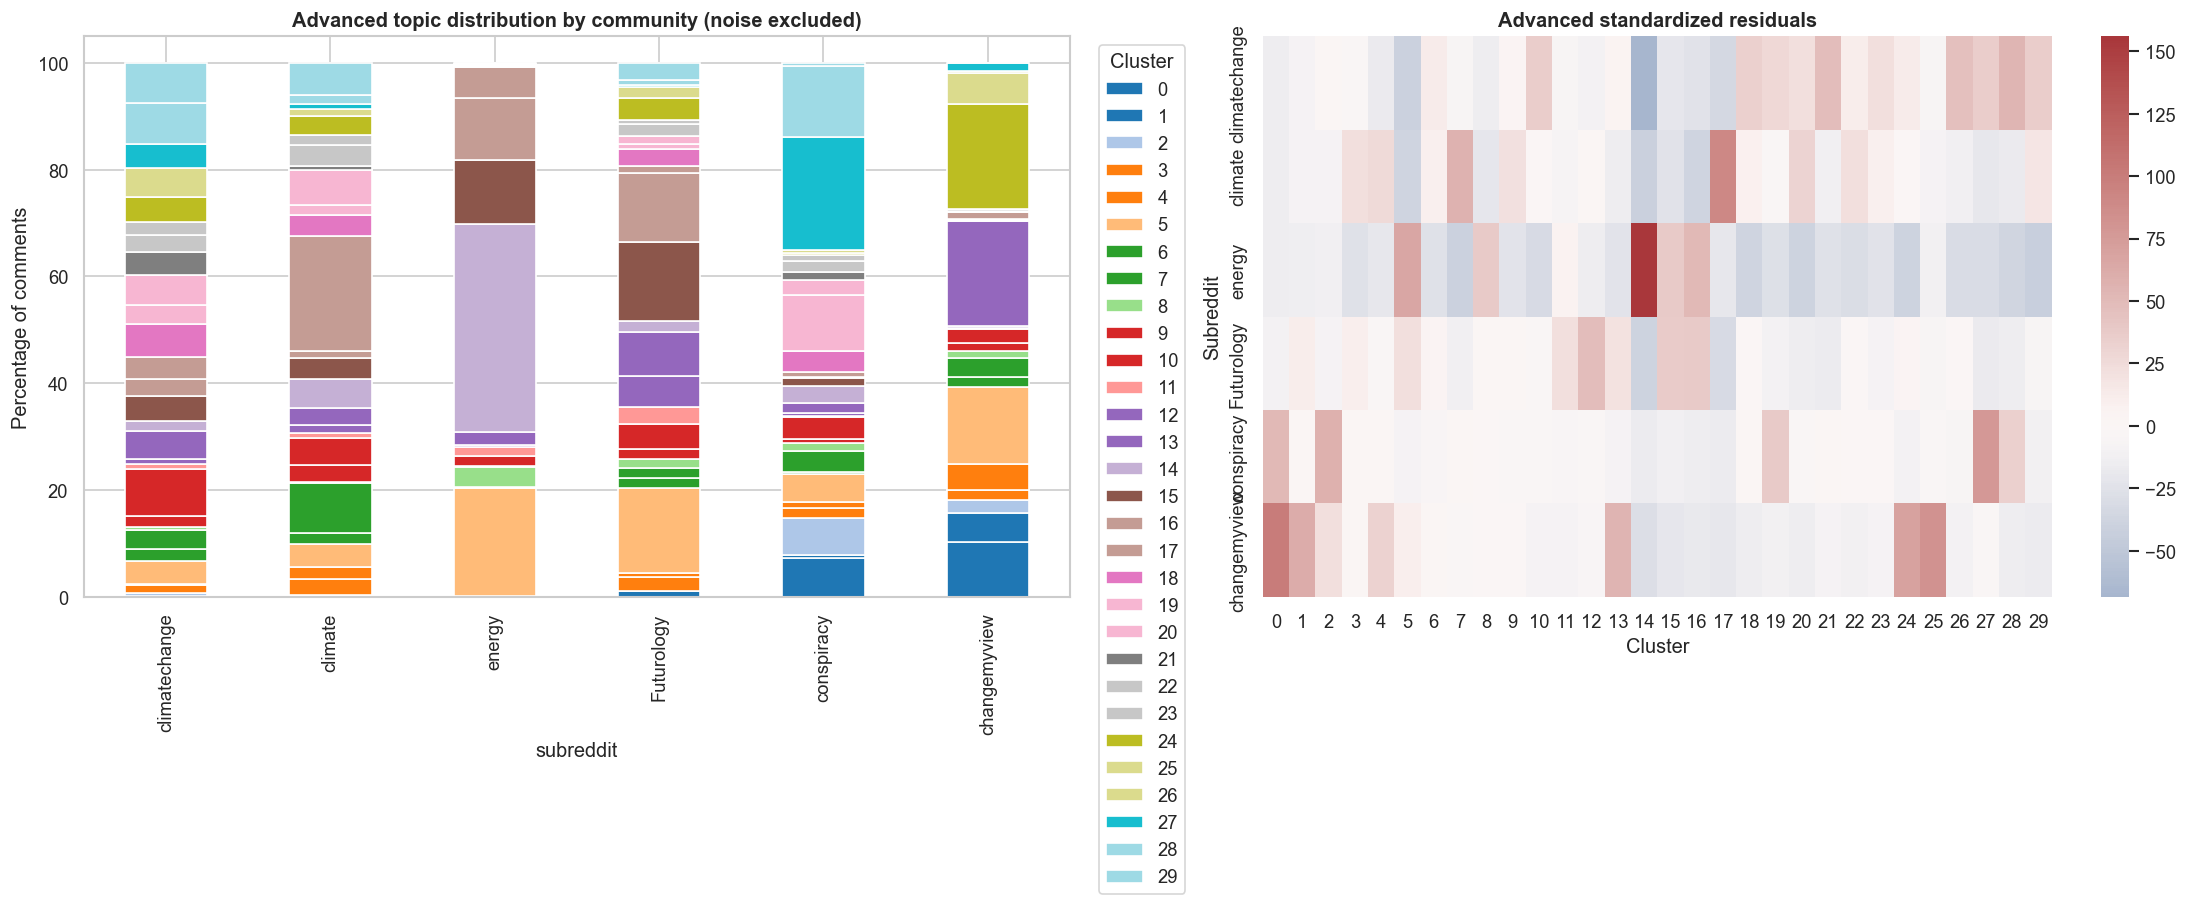

In [15]:
def association_outputs(frame, label_column):
    counts = pd.crosstab(frame["subreddit"], frame[label_column]).reindex(SELECTED_SUBREDDITS)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    chi2, p_value, dof, expected = chi2_contingency(counts)
    n = counts.to_numpy().sum()
    denominator = max(1, min(counts.shape[0] - 1, counts.shape[1] - 1))
    cramers_v = np.sqrt((chi2 / n) / denominator)
    residuals = (counts - expected) / np.sqrt(expected)
    return counts, percentages, chi2, p_value, dof, cramers_v, residuals


if ASSIGN_FULL_CORPUS:
    advanced_noise_by_subreddit = (
        analysis_df.assign(is_advanced_noise=analysis_df["advanced_cluster"].eq(-1))
        .groupby("subreddit")["is_advanced_noise"].mean()
        .reindex(SELECTED_SUBREDDITS)
        .rename("noise_rate")
    )
    advanced_assigned_df = analysis_df.loc[analysis_df["advanced_cluster"].ge(0)]
    advanced_counts, advanced_percentages, advanced_chi2, advanced_p, advanced_dof, advanced_v, advanced_residuals = association_outputs(
        advanced_assigned_df, "advanced_cluster"
    )
    baseline_counts, baseline_percentages, baseline_chi2, baseline_p, baseline_dof, baseline_v, baseline_residuals = association_outputs(
        analysis_df, "baseline_cluster"
    )

    display(advanced_noise_by_subreddit.to_frame())
    display(advanced_counts)
    display(advanced_percentages.round(2))
    print("Advanced chi-square:", f"{advanced_chi2:,.2f}")
    print("Advanced p-value:", f"{advanced_p:.4g}")
    print("Advanced Cramer's V:", f"{advanced_v:.4f}")
    print("Baseline Cramer's V:", f"{baseline_v:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(19, 7))
    advanced_percentages.plot(kind="bar", stacked=True, colormap="tab20", ax=axes[0])
    axes[0].set_title("Advanced topic distribution by community (noise excluded)")
    axes[0].set_ylabel("Percentage of comments")
    axes[0].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.heatmap(advanced_residuals, center=0, cmap="vlag", ax=axes[1])
    axes[1].set_title("Advanced standardized residuals")
    axes[1].set_xlabel("Cluster")
    axes[1].set_ylabel("Subreddit")
    plt.tight_layout()
    plt.show()

Result guide: Noise rates are reported first, then excluded from the topic-distribution comparison. Percentages answer the descriptive part of RQ2. Large positive residuals identify community-topic combinations occurring more often than expected.

结果说明：先报告各社区噪声率，再从主题分布比较中排除噪声。百分比回答RQ2的描述部分，较大的正残差表示某社区—主题组合高于期望。

## 16. Save models, assignments, and comparison tables / 16. 保存模型、分配结果与比较表

Save all reproducible outputs to a separate folder. The original cleaned data and the previous notebook are not overwritten.

把全部可复现结果保存到独立文件夹，不覆盖原始清洗数据和之前的notebook。

In [16]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_search_df.to_csv(OUTPUT_DIR / "baseline_k_search.csv", index=False, encoding="utf-8-sig")
baseline_comparison_df.to_csv(OUTPUT_DIR / "baseline_variants.csv", index=False, encoding="utf-8-sig")
baseline_stability_df.to_csv(OUTPUT_DIR / "baseline_stability.csv", index=False, encoding="utf-8-sig")
baseline_terms_df.to_csv(OUTPUT_DIR / "baseline_topic_terms.csv", index=False, encoding="utf-8-sig")
baseline_representatives_df.to_csv(OUTPUT_DIR / "baseline_representative_comments.csv", index=False, encoding="utf-8-sig")
dbscan_search_df.to_csv(OUTPUT_DIR / "course_dbscan_search.csv", index=False, encoding="utf-8-sig")
course_metrics_df.to_csv(OUTPUT_DIR / "course_method_metrics.csv", index=False, encoding="utf-8-sig")
advanced_search_df.to_csv(OUTPUT_DIR / "advanced_hdbscan_search.csv", index=False, encoding="utf-8-sig")
advanced_stability_df.to_csv(OUTPUT_DIR / "advanced_parameter_stability.csv", index=False, encoding="utf-8-sig")
advanced_terms_df.to_csv(OUTPUT_DIR / "advanced_topic_terms.csv", index=False, encoding="utf-8-sig")
advanced_representatives_df.to_csv(OUTPUT_DIR / "advanced_representative_comments.csv", index=False, encoding="utf-8-sig")
comparison_df.to_csv(OUTPUT_DIR / "baseline_vs_advanced_comparison.csv", index=False, encoding="utf-8-sig")
relevance_audit.to_csv(OUTPUT_DIR / "relevance_audit.csv", encoding="utf-8-sig")

joblib.dump(vectorizer, OUTPUT_DIR / "baseline_tfidf_vectorizer.joblib")
joblib.dump(lsa, OUTPUT_DIR / "baseline_lsa.joblib")
joblib.dump(normalizer, OUTPUT_DIR / "baseline_lsa_normalizer.joblib")
joblib.dump(baseline_model, OUTPUT_DIR / "baseline_kmeans.joblib")
joblib.dump(umap_model, OUTPUT_DIR / "advanced_umap.joblib")
joblib.dump(advanced_model, OUTPUT_DIR / "advanced_hdbscan.joblib")

if ASSIGN_FULL_CORPUS:
    final_columns = [column for column in analysis_df.columns if column != "model_text"]
    final_path = BASE_DIR / "reddit_climate_baseline_advanced_clusters.parquet"
    analysis_df[final_columns].to_parquet(final_path, index=False)
    advanced_cluster_summary.to_csv(OUTPUT_DIR / "advanced_cluster_summary.csv", index=False, encoding="utf-8-sig")
    baseline_cluster_summary.to_csv(OUTPUT_DIR / "baseline_cluster_summary.csv", index=False, encoding="utf-8-sig")
    advanced_counts.to_csv(OUTPUT_DIR / "advanced_subreddit_cluster_counts.csv", encoding="utf-8-sig")
    advanced_percentages.to_csv(OUTPUT_DIR / "advanced_subreddit_cluster_percentages.csv", encoding="utf-8-sig")
    advanced_residuals.to_csv(OUTPUT_DIR / "advanced_standardized_residuals.csv", encoding="utf-8-sig")
    advanced_noise_by_subreddit.to_csv(OUTPUT_DIR / "advanced_noise_rate_by_subreddit.csv", encoding="utf-8-sig")
    print("Saved clustered corpus:", final_path)

run_metadata = {
    "input_file": str(DATA_PATH),
    "stance_data_used": False,
    "subreddits": SELECTED_SUBREDDITS,
    "start_date": str(START_DATE.date()),
    "end_date_inclusive": str((END_EXCLUSIVE - pd.Timedelta(days=1)).date()),
    "minimum_words": MIN_WORDS,
    "common_modeling_sample": int(len(model_df)),
    "training_comments_per_subreddit": int(TRAIN_PER_SUBREDDIT),
    "baseline_k": int(BASELINE_K),
    "embedding_model": EMBEDDING_MODEL_NAME,
    "advanced_parameters": {
        "min_cluster_size": int(selected_parameters[0]),
        "min_samples": int(selected_parameters[1]),
    },
    "advanced_clusters": int(len(set(advanced_labels[advanced_labels >= 0]))),
    "advanced_training_noise_share": float((advanced_labels < 0).mean()),
    "random_state": RANDOM_STATE,
}
with open(OUTPUT_DIR / "run_metadata.json", "w", encoding="utf-8") as file:
    json.dump(run_metadata, file, ensure_ascii=False, indent=2)

print("Saved models and tables:", OUTPUT_DIR)

Saved clustered corpus: D:\DM1_project\reddit_climate_baseline_advanced_clusters.parquet
Saved models and tables: D:\DM1_project\baseline_vs_advanced_outputs


Result guide: The final Parquet contains both baseline and advanced labels. The output folder preserves metrics, terms, examples, models, and metadata required for reporting and reproducibility.

结果说明：最终Parquet同时包含基线和高级聚类标签。输出文件夹保存报告及复现所需的指标、关键词、示例、模型和元数据。

## Interpretation rules and next steps / 解释规则与下一步

Do not choose the advanced method only because it is more complex. Prefer it only if semantic separation, topic clarity, stability, and community-level usefulness improve enough to justify its noise rate and computational cost.

不要仅因为高级方法更复杂就选择它。只有当语义分离、主题清晰度、稳定性和社区比较价值的改善足以抵消噪声率及计算成本时，才应优先采用。

The final report should present the K-means++ pipeline as the course baseline, Ward and DBSCAN as diagnostic comparisons, and SBERT-UMAP-HDBSCAN as the advanced response to lexical overlap, non-globular structure, varying density, and forced assignment.

最终报告应把K-means++作为课程基线，把Ward和DBSCAN作为诊断比较，并把SBERT-UMAP-HDBSCAN作为针对词汇重叠、非球形结构、不同密度和强制分配问题的高级方法。

After execution, manually name topics from the term and representative-comment tables, then update the result markdown cells with the observed values.

运行后，应根据关键词表和代表性评论人工命名主题，再用实际结果更新各结果说明markdown单元。